In [4]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

def is_independent(X, Y, Z):
    """
    使用皮尔逊相关系数来测试X和Y在给定Z的条件下是否独立。
    """
    # 计算X和Y的皮尔逊相关系数
    r_xy = pearsonr(X, Y)[0]
    # 计算X和Z的皮尔逊相关系数
    r_xz = pearsonr(X, Z)[0]
    # 计算Y和Z的皮尔逊相关系数
    r_yz = pearsonr(Y, Z)[0]
    # 计算条件相关系数
    r_xy_z = (r_xy - r_xz * r_yz) / np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    return abs(r_xy_z) < 0.5  # 0.5是一个阈值，可以根据需要调整

def sgs_algorithm(data, alpha=0.05):
    """
    实现SGS算法来发现因果结构。
    """
    num_vars = data.shape[1]
    adjacency_matrix = pd.DataFrame(np.ones((num_vars, num_vars)), columns=data.columns, index=data.columns)
    
    for i in range(num_vars):
        for j in range(i+1, num_vars):
            conditions = data.drop([data.columns[i], data.columns[j]], axis=1)
            if is_independent(data[data.columns[i]], data[data.columns[j]], conditions.values.flatten()):
                adjacency_matrix.at[data.columns[i], data.columns[j]] = 0
                adjacency_matrix.at[data.columns[j], data.columns[i]] = 0
    
    return adjacency_matrix

# 生成一些示例数据
np.random.seed(42)
data = pd.DataFrame(np.random.multivariate_normal([0, 0, 0], [[1, 0.5, 0.2], [0.5, 1, 0.3], [0.2, 0.3, 1]], size=1000), columns=['X', 'Y', 'Z'])

# 运行SGS算法
causal_structure = sgs_algorithm(data)
print(causal_structure)

     X    Y    Z
X  1.0  0.0  0.0
Y  0.0  1.0  0.0
Z  0.0  0.0  1.0


In [5]:
pip install tigramite

Defaulting to user installation because normal site-packages is not writeable
     ------------------------------------ 298.7/298.7 kB 803.4 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.data_processing import DataFrame

# 生成一些示例数据
np.random.seed(42)
data = np.random.multivariate_normal([0, 0, 0], [[1, 0.5, 0.2], [0.5, 1, 0.3], [0.2, 0.3, 1]], size=1000)
data = DataFrame(data, var_names=['X', 'Y', 'Z'])

# 初始化PCMCI对象
pcmci = PCMCI(data, cond_ind_test=ParCorr())
results = pcmci.run_pcmci(tau_max=2, pc_alpha=0.05)

# 打印结果
print(results)

{'graph': array([[['', '', ''],
        ['o-o', '', ''],
        ['o-o', '', '']],

       [['o-o', '', ''],
        ['', '', ''],
        ['o-o', '', '']],

       [['o-o', '', ''],
        ['o-o', '', ''],
        ['', '', '']]], dtype='<U3'), 'p_matrix': array([[[1.00000000e+00, 7.55157121e-01, 2.10102152e-01],
        [1.01172880e-63, 3.90648287e-01, 8.39461729e-01],
        [4.30154638e-06, 7.44552696e-01, 8.88332487e-01]],

       [[1.01172880e-63, 2.40258675e-01, 6.33416957e-02],
        [1.00000000e+00, 8.13724803e-01, 7.70677100e-01],
        [4.16181407e-18, 7.64341938e-01, 4.14400328e-01]],

       [[4.30154638e-06, 8.32741406e-01, 2.33016064e-01],
        [4.16181407e-18, 5.75174011e-02, 1.00481730e-01],
        [1.00000000e+00, 7.26106784e-01, 9.71392908e-01]]]), 'val_matrix': array([[[ 0.        , -0.00989342,  0.03974606],
        [ 0.49862239,  0.02722993,  0.00642706],
        [ 0.14504917, -0.01033704, -0.00445478]],

       [[ 0.49862239, -0.03724426,  0.0588574 ],
 

graph: 这是一个邻接矩阵，用于表示变量之间的因果关系。矩阵中的每个元素是一个字符串，表示两个变量之间的关系：

'' 表示两个变量之间没有直接的因果关系。
'o-o' 表示两个变量之间存在直接的因果关系，箭头可以是双向的，表示这两个变量可能相互影响。
p_matrix: 这是p值矩阵，用于表示在给定其他变量的情况下，两个变量之间条件独立的统计显著性。矩阵中的每个元素是一个数组，包含三个值：

第一个值是p值，表示在给定其他变量的情况下，两个变量之间条件独立的统计显著性。
第二个和第三个值可能是与条件独立性测试相关的其他统计量。
val_matrix: 这是值矩阵，用于存储条件独立性测试的结果值。这些值可以是相关系数、回归系数或其他统计量，用于评估两个变量在给定其他变量的情况下的依赖性。

conf_matrix: 这是置信矩阵，但在输出中为None，可能表示没有计算或没有提供置信区间。

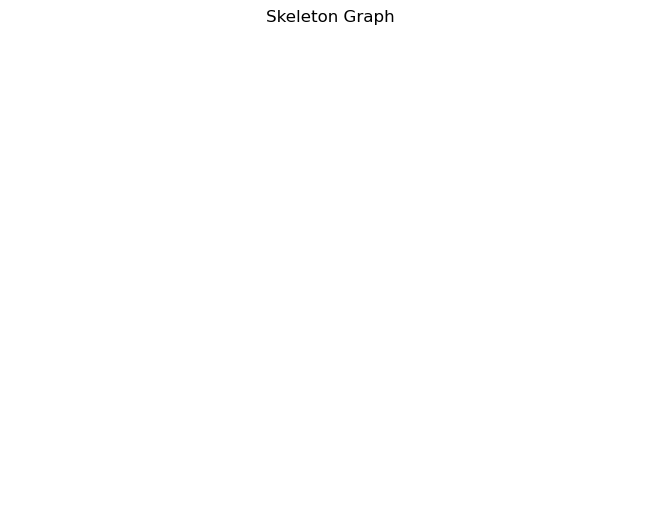

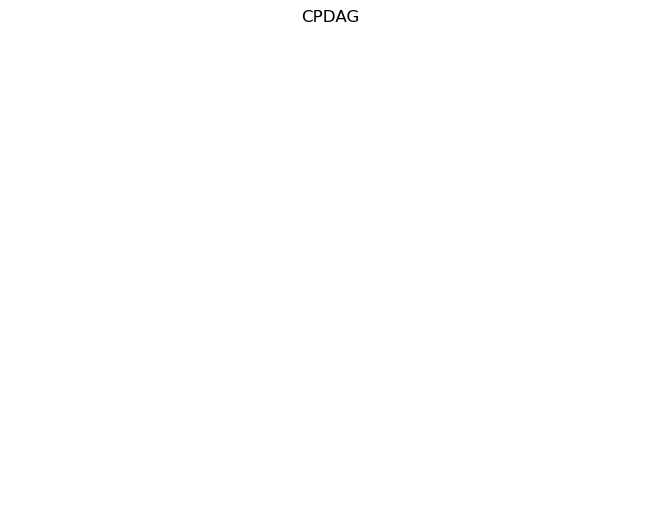

In [8]:

%matplotlib inline
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 模拟一些数据
np.random.seed(42)
data = np.random.multivariate_normal([0, 0, 0], [[1, 0.5, 0.2], [0.5, 1, 0.3], [0.2, 0.3, 1]], size=100)

# 计算相关系数矩阵
corr_matrix = np.corrcoef(data, rowvar=False)

# 构建无向图骨架
def make_skeleton(corr_matrix, threshold=0.7):
    G = nx.Graph()
    for i in range(corr_matrix.shape[0]):
        for j in range(i+1, corr_matrix.shape[0]):
            if abs(corr_matrix[i, j]) > threshold:
                G.add_edge(i, j)
    return G

# 扩展骨架为CPDAG（这里仅作为演示，不实现完整的PC算法扩展规则）
def extend_skeleton(G):
    # 这里应该实现PC算法的扩展规则，但为了简单起见，我们假设所有边都是因果关系
    DAG = G.copy()
    return DAG

# 绘制图形
def draw_graph(G, title):
    pos = nx.spring_layout(G)  # 为了简化，使用spring布局
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
    plt.title(title)
    plt.show()

# 运行PC算法
skeleton = make_skeleton(corr_matrix)
dag = extend_skeleton(skeleton)

# 绘制骨架和CPDAG
draw_graph(skeleton, "Skeleton Graph")
draw_graph(dag, "CPDAG")

In [5]:
import numpy as np
import pandas as pd
from itertools import combinations
import math
from scipy.stats import norm
import networkx as nx
from matplotlib import pyplot as plt
from scipy.linalg import pinv2

#构建无向的skeleton
def make_skeleton(V, corr_matrix, sample_num):
    #输入节点列表
    node_num = len(V)
    C = np.ones((node_num, node_num))    #先构造一个完全图
    #构造空的分离集
    S = []
    for i in range(node_num):
        S.append([])
        for j in range(node_num):
            S[i].append([])
    
    pairs = []
    #构造点对列表
    for i in range(node_num):
        for j in range(node_num - i):
            if(i != (node_num - j - 1)):    #不要把(i,i)加进去
                pairs.append((i, (node_num - j - 1)))
            else:
                #在这里顺便把对角线的点变为0
                C[i, i] = 0
    
    l = -1    #初始化l
    while 1:
        l = l + 1
        flag = True    #用来判断是否所有的邻接集的大小都小于l
        for (i, j) in pairs:

            adj_set = get_adjSet(i, C, node_num)    #获得i的邻接点集
            

            if(C[i][j] == 1) & (len(adj_set) >= l):    #如果两个点邻接，且邻接点集大小大于l
                flag =False    #一旦进入这个if，说明存在，所以不应该推出循环
                adj_set.remove(j)    #邻接点集去掉j

                combin_set = combinations(adj_set, l)    #获得K集合长度为l的全部情况
                for K in combin_set:
                    if indep_judge(i, j, list(K), corr_matrix, sample_num):
                        #如果i,j在K的条件下独立，则去掉i,j间的边，并把K集合加入到分离集中
                        C[i][j] = 0
                        C[j][i] = 0
                        #pairs.remove((i, j))    #已经独立的点对不需要再进行判断了
                        S[i][j] = list(K)
                        S[j][i] = list(K)
                        break    #如果证明了i和j独立，则没必要再判断了
                    else:
                        continue
            else:
                continue
        
        #判断是否该推出循环
        if flag:
            break

    return C, S

#判断i和j是否在K集合的条件下相互独立
def indep_judge(i, j, K, corr_matrix, sample_num):
    #输入与判断独立性的i,j以及分离集K
    #corr_matrix是相关系数矩阵
    indep = True

    #计算条件偏相关系数
    if len(K) == 0:
        #条件集为空，那么条件偏相关系数就是两个点的相关系数
        r = corr_matrix[i, j]
    else:
        corr = corr_matrix[np.ix_([i] + [j] + K, [i] + [j] + K)]
        #先通过对相关系数矩阵求逆得到偏相关系数矩阵
        partial_corr = np.linalg.pinv(corr)    #求广义逆矩阵
        #partial_corr = pinv2(corr)
        #然后取偏相关系数求条件偏相关系数
        #条件偏相关系数求法：-1*pr(x,y)/sqrt(pr(x,x)*pr(y,y))
        r = (-1 * partial_corr[0, 1]) / (math.sqrt(abs(partial_corr[0, 0] * partial_corr[1, 1])))
    
    #把r压缩到(-1, 1)之中
    r = min(0.99999, max(r, -0.99999))     #大于1的都归到1，小于-1都归到-1

    #进行fisher变换
    z = 0.5 * math.log1p((2 * r) / (1 - r))    #因为log1p是ln(1+x)，所以要减1
    #进行fisher变换后z服从正态分布，把其变成标准正态变量
    z_standard = z * math.sqrt(sample_num - len(K) - 3)

    #假设检验变量落在置信区间中
    alpha = 0.005    #置信度
    if 2 * (1 - norm.cdf(abs(z_standard))) >= alpha:
        indep = True
    else:
        indep = False
    return indep

#把无向的skeleton扩展成CPDAG
def extend_CPDAG(V, C, S):
    #输入无向的skeleton-C，分离集S
    #V是顶点集，C是skeleton，S是分离集
    G = C
    node_num = len(V)

    #先找到所有的三元组，因为之后的规则都是用在三元组上的。
    #先寻找所有相邻的二元组，再去找三元组
    pairs = []
    for i in range(node_num):
        for j in range(node_num):
            if(i != j):    #除去对角元素
                if(C[i][j] == 1):
                    pairs.append((i, j))
    
    triples = []
    for (i, j) in pairs:
        for k in range(node_num):
            if(C[j][k] == 1) & (k != i):
                triples.append([i, j, k])
    
    #构造PDAG。对于i-j-k，若j不在分离集(S[i][k])中，且i,k不相邻,则：i -> j <- k
    for [i, j, k] in triples:
        if (G[i][j] == 1) & (G[j][i] == 1) & (G[k][j] == 1) & (G[j][k] == 1) & (G[i][k] == 0) & (
            G[k][i] == 0):    #保证是i-j-k
            if j not in S[i][k]:
                G[j][i] = 0
                G[j][k] = 0

    #rule1:对于i -> j - k，如果i,k不相邻，则：i -> j -> k  （因为i<-j->k已经全部找出来了)
    for [i, j, k] in triples:
        if (G[i][j] == 1) & (G[j][i] == 0) & (G[k][j] == 1) & (G[j][k] == 1) & (G[i][k] == 0) & (
            G[k][i] == 0):
            G[k][j] = 0

    #rule2:对于i -> j -> k，且:i - k，则：i -> k （很显然是为了不能构成环）
    for [i, j, k] in triples:
        if (G[i][j] == 1) & (G[j][i] == 0) & (G[j][k] == 1) & (G[k][j] == 0) & (G[i][k] == 1) & (
            G[k][i] == 1):
            G[k][i] = 0

    #rule3:对于i-j->k,i-l->k,i-k，则：i->k
    for [i, j ,k] in triples:
        for [l, m, n] in triples:
            if (i == l) & (k == n):    #先找出i-j-k和i-l-k
                if (G[i][j] == 1) & (G[j][i] == 1) & (G[i][m] == 1) & (G[m][i] == 1) & (G[j][k] == 1
                ) & (G[k][j] == 0) & (G[m][k] == 1) & (G[k][m] == 0) & (G[i][k] == 1) & (G[k][i] == 1):
                    G[k][i] = 0

    #rule4:对于i-j->k,j->k->l,i-l，则：i->l
    for [i, j ,k] in triples:
        for [l, m, n] in triples:
            if (j == l) & (k == m):    #先找出i-j-k和j-k-l
                if (G[i][j] == 1) & (G[j][i] == 1) & (G[j][k] == 1) & (G[k][j] == 0) & (G[k][n] == 1
                ) & (G[n][k] == 0) & (G[i][n] == 1) & (G[n][i] == 1):
                    G[n][i] = 0

    return G

#获取点i在图G中的临界点集
def get_adjSet(i, G, node_num):
    adj = []
    for j in range(node_num):
        if G[i][j] == 1:
            adj.append(j)
    return adj

#使用networkx画图
def Draw(DAG, nodes):
    G = nx.DiGraph()
    nodes = nodes.tolist()
    G.add_nodes_from(nodes)    #加入所有的点
    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if DAG[i][j] == 1:
                G.add_edge(nodes[i], nodes[j])
    nx.draw(G, with_labels=True)
    plt.show()


def PC(data_path):
    df = pd.read_csv(data_path, index_col=False)    #不读取行序号

    #计算相关系数矩阵
    corr = df.corr().values
    #样本的个数
    sample_num = df.values.shape[0]

    node = df.columns.values

    skeleton, separate = make_skeleton(node, corr, sample_num)
    CPDAG = extend_CPDAG(node, skeleton, separate)
    #print(CPDAG)
    #Draw(CPDAG, node)
    return CPDAG


if __name__ == '__main__':
    #data_path = r'./data/test.csv'
    data_path = r'D:\学校工作\工作\课件\健康数据挖掘\新建文件夹 (2)/SimulateData.csv'
    PC(data_path)

ImportError: cannot import name 'pinv2' from 'scipy.linalg' (D:\software\Anaconda\Anaconda3\lib\site-packages\scipy\linalg\__init__.py)

In [9]:
import numpy as np
import scipy.linalg as slin
import scipy.optimize as sopt
from scipy.special import expit as sigmoid


def notears_linear(X, lambda1, loss_type, max_iter=100, h_tol=1e-8, rho_max=1e+16, w_threshold=0.3):
    """Solve min_W L(W; X) + lambda1 ‖W‖_1 s.t. h(W) = 0 using augmented Lagrangian.

    Args:
        X (np.ndarray): [n, d] sample matrix
        lambda1 (float): l1 penalty parameter
        loss_type (str): l2, logistic, poisson
        max_iter (int): max num of dual ascent steps
        h_tol (float): exit if |h(w_est)| <= htol
        rho_max (float): exit if rho >= rho_max
        w_threshold (float): drop edge if |weight| < threshold

    Returns:
        W_est (np.ndarray): [d, d] estimated DAG
    """
    def _loss(W):
        """Evaluate value and gradient of loss."""
        M = X @ W
        if loss_type == 'l2':
            R = X - M
            loss = 0.5 / X.shape[0] * (R ** 2).sum()
            G_loss = - 1.0 / X.shape[0] * X.T @ R
        elif loss_type == 'logistic':
            loss = 1.0 / X.shape[0] * (np.logaddexp(0, M) - X * M).sum()
            G_loss = 1.0 / X.shape[0] * X.T @ (sigmoid(M) - X)
        elif loss_type == 'poisson':
            S = np.exp(M)
            loss = 1.0 / X.shape[0] * (S - X * M).sum()
            G_loss = 1.0 / X.shape[0] * X.T @ (S - X)
        else:
            raise ValueError('unknown loss type')
        return loss, G_loss

    def _h(W):
        """Evaluate value and gradient of acyclicity constraint."""
        E = slin.expm(W * W)  # (Zheng et al. 2018)
        h = np.trace(E) - d
        #     # A different formulation, slightly faster at the cost of numerical stability
        #     M = np.eye(d) + W * W / d  # (Yu et al. 2019)
        #     E = np.linalg.matrix_power(M, d - 1)
        #     h = (E.T * M).sum() - d
        G_h = E.T * W * 2
        return h, G_h

    def _adj(w):
        """Convert doubled variables ([2 d^2] array) back to original variables ([d, d] matrix)."""
        return (w[:d * d] - w[d * d:]).reshape([d, d])

    def _func(w):
        """Evaluate value and gradient of augmented Lagrangian for doubled variables ([2 d^2] array)."""
        W = _adj(w)
        loss, G_loss = _loss(W)
        h, G_h = _h(W)
        obj = loss + 0.5 * rho * h * h + alpha * h + lambda1 * w.sum()
        G_smooth = G_loss + (rho * h + alpha) * G_h
        g_obj = np.concatenate((G_smooth + lambda1, - G_smooth + lambda1), axis=None)
        return obj, g_obj

    n, d = X.shape
    w_est, rho, alpha, h = np.zeros(2 * d * d), 1.0, 0.0, np.inf  # double w_est into (w_pos, w_neg)
    bnds = [(0, 0) if i == j else (0, None) for _ in range(2) for i in range(d) for j in range(d)]
    if loss_type == 'l2':
        X = X - np.mean(X, axis=0, keepdims=True)
    for _ in range(max_iter):
        w_new, h_new = None, None
        while rho < rho_max:
            sol = sopt.minimize(_func, w_est, method='L-BFGS-B', jac=True, bounds=bnds)
            w_new = sol.x
            h_new, _ = _h(_adj(w_new))
            if h_new > 0.25 * h:
                rho *= 10
            else:
                break
        w_est, h = w_new, h_new
        alpha += rho * h
        if h <= h_tol or rho >= rho_max:
            break
    W_est = _adj(w_est)
    W_est[np.abs(W_est) < w_threshold] = 0
    return W_est


if __name__ == '__main__':
    from notears import utils
    utils.set_random_seed(1)

    n, d, s0, graph_type, sem_type = 100, 20, 20, 'ER', 'gauss'
    B_true = utils.simulate_dag(d, s0, graph_type)
    W_true = utils.simulate_parameter(B_true)
    np.savetxt('W_true.csv', W_true, delimiter=',')

    X = utils.simulate_linear_sem(W_true, n, sem_type)
    np.savetxt('X.csv', X, delimiter=',')

    W_est = notears_linear(X, lambda1=0.1, loss_type='l2')
    assert utils.is_dag(W_est)
    np.savetxt('W_est.csv', W_est, delimiter=',')
    acc = utils.count_accuracy(B_true, W_est != 0)
    print(acc)



ModuleNotFoundError: No module named 'notears'